# Упражнение 11.3. Полуградиентное Q-обучение на контрпримере Бэрда

Саттон, Барто, «Обучение с подкреплением».
Полный разбор — в сборнике решений: [глава 11 (PDF)](https://michaeltoschenko.github.io/RL_Sutton_Barto_Solutions/ch11.pdf).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Контрпример Бэрда

7 состояний (6 верхних и 7-е) и 2 действия. Действие solid детерминированно ведёт в 7-е состояние, dashed - в случайное из шести верхних. Награда всюду 0, дисконт 0.99. Поведенческая стратегия b: dashed с вероятностью 6/7, solid с вероятностью 1/7 (это даёт равномерное посещение состояний). Целевая стратегия Q-обучения - жадная по q.

Линейная аппроксимация с вектором весов из 8 компонент (индексы 0..5 - это w1..w6, индекс 6 - w7, индекс 7 - w8). Ценности действий повторяют структуру признаков Бэрда: solid ведёт в 7-е состояние, поэтому его ценность w7 + 2 w8; dashed из верхнего состояния i имеет ценность 2 wi + w8. Общий вес w8 входит во все состояния - именно через него система и раздувается.

In [2]:
GAMMA = 0.99

def feat(s, a):
    x = np.zeros(8)
    if a == 1:                 # solid -> 7-е состояние: w7 + 2 w8
        x[6] = 1.0; x[7] = 2.0
    else:                      # dashed
        if s <= 5:             # верхнее состояние i: 2 wi + w8
            x[s] = 2.0; x[7] = 1.0
        else:                  # dashed из 7-го
            x[6] = 1.0; x[7] = 2.0
    return x

def q(w, s, a):
    return w @ feat(s, a)

def successor(s, a, rng):
    if a == 1:
        return 6               # solid -> 7-е состояние
    return rng.integers(0, 6)  # dashed -> случайное верхнее (0..5)

## Алгоритм

Одношаговое полуградиентное Q-обучение: на каждом шаге берём действие по поведенческой b, обновляем q(S,A) к цели R + GAMMA * max_a q(S',a). Коэффициента выборки по значимости нет - цель строится по жадному действию напрямую. Начальные веса как в книге: w = (1,1,1,1,1,1,10,1), шаг alpha = 0.01.

In [3]:
def run(n_steps=1000, alpha=0.01, seed=0):
    rng = np.random.default_rng(seed)
    w = np.array([1, 1, 1, 1, 1, 1, 10, 1], dtype=float)
    hist = np.zeros((n_steps + 1, 8))
    hist[0] = w
    s = rng.integers(0, 7)
    for t in range(n_steps):
        a = 1 if rng.random() < 1/7 else 0                    # поведенческая b: solid 1/7, dashed 6/7
        s2 = successor(s, a, rng)
        target = 0.0 + GAMMA * max(q(w, s2, 0), q(w, s2, 1))  # Q-обучение: max по действиям
        delta = target - q(w, s, a)
        w = w + alpha * delta * feat(s, a)
        hist[t + 1] = w
        s = s2
    return hist

## Запуск и график

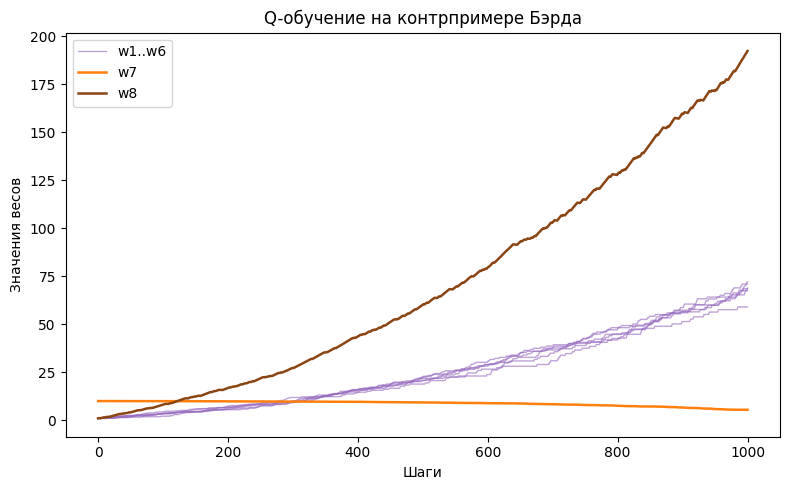

In [4]:
hist = run(n_steps=1000, alpha=0.01, seed=0)
steps = np.arange(hist.shape[0])

plt.figure(figsize=(8, 5))
for i in range(6):
    plt.plot(steps, hist[:, i], color='tab:purple', alpha=0.6, linewidth=1,
             label='w1..w6' if i == 0 else None)
plt.plot(steps, hist[:, 6], color='tab:orange', linewidth=1.8, label='w7')
plt.plot(steps, hist[:, 7], color='saddlebrown', linewidth=1.8, label='w8')
plt.xlabel('Шаги')
plt.ylabel('Значения весов')
plt.title('Q-обучение на контрпримере Бэрда')
plt.legend()
plt.tight_layout()
plt.show()